# QCAP-style bounding 2 Qubit Example

**Goal of this notebook**
We will simulate a small 2‑qubit quantum processor with noise, then:
- use **RC (Randomized Compiling)** around a CZ gate to “twirl” errors,
- use **CB (Cycle Benchmarking)** to estimate a process parameter \(e_F\),
- use a **readout confusion matrix** to estimate \(r_o\) parameters,
- plug those into a **QCAP bound** formula to predict how the error grows with circuit depth,
- and compare the prediction to measured metrics like **TVD** and **Hellinger fidelity**.

This is a meant to pedogocial and I will explain each idea from scratch.

## 0) Background: what are we measuring?

A quantum circuit prepares a quantum state, then we measure it in the computational (Z) basis.

- If the circuit were perfect, we’d get an *ideal* probability distribution $p(x)$.
- With noise, we get a *measured* distribution $q(x)$.

So we need tools to compare distributions:
- **TVD** (total variation distance) tells how distinguishable the two distributions are.
- **Hellinger fidelity** (a distribution fidelity) is another comparison measure.
- We also compute the **Shannon entropy** of the ideal distribution to study correlation with looseness of the bound.

We’ll also need a way to understand how noise behaves across repeated “cycles” of the gate.
That’s what **RC** and **CB** help with.

In [ ]:
!pip install qiskit
!pip install qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 70.1 MB/s eta 0:00:00


In [ ]:
# Import Packages

import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, random_unitary
from qiskit_aer import AerSimulator
from qiskit_aer.noise import (
    NoiseModel,
    depolarizing_error,
    coherent_unitary_error,
    ReadoutError,
)

from scipy.optimize import curve_fit
from scipy.linalg import expm

In [ ]:
# Circuit Config

SEED = 0
rng = np.random.default_rng(SEED)

# Two-qubit toy model
N_QUBITS = 2

# Depths we will test (number of "cycles" in the circuits)
DEPTHS = [1, 2, 4, 8, 16, 32, 64, 128]

# For CB fitting: cycle lengths m that we try
CB_DEPTHS = [4, 16, 32, 64, 128]

# For each depth, how many random circuit instances we run
N_CIRC_PER_DEPTH = 50

# Shots (samples) per circuit execution
SHOTS = 4096

# RC averaging (we will average over multiple RC randomizations)
N_RC = 30

# CB: average over RC randomizations too
CB_N_RC = 20
CB_SHOTS = 4096

# -------------------------
# Noise model parameters
# -------------------------
p1 = 1e-3          # 1-qubit depolarizing strength
p2 = 1e-2          # 2-qubit depolarizing strength
cz_overrot = 0.08  # coherent CZ over-rotation magnitude
zz_angle = 0.06    # coherent ZZ component magnitude

# Symmetric readout error per qubit
p_readout = 0.02

sim = AerSimulator()

## 1) The noise model: what are we simulating?

Real hardware has multiple error sources:
1. **Gate noise**: gates implement the wrong operation.
   - We include a **coherent** error on CZ (a unitary over/under-rotation).
   - We also include **depolarizing** noise (randomizing error).
2. **Readout noise**: measurement can flip 0↔1 with some probability.

We build a `NoiseModel` for Qiskit Aer that includes:
- 1-qubit depolarizing noise after common 1-qubit gate types
- a special noisy channel for `cz`
- a 2-qubit readout confusion model (built from per-qubit symmetric bit flips)

In [ ]:
# Noise Model

def build_noise_model(
    p1=1e-3,
    p2=1e-2,
    cz_overrot=0.08,
    zz_angle=0.06,
    p_readout=0.02,
):
    nm = NoiseModel()

    # 1-qubit depolarizing error
    oneq_depol = depolarizing_error(p1, 1)

    # Apply this depol after common 1q gate names
    # (so the simulator remains consistent even if the transpiler uses different names)
    for g in ["id", "h", "x", "y", "z", "sx", "rz", "u", "s", "sdg", "unitary"]:
        nm.add_all_qubit_quantum_error(oneq_depol, [g])

    # Build coherent ZZ-like error unitary for CZ:
    # Use exp(-i (angle/2) Z⊗Z), then combine the over-rotation and static ZZ component.
    ZZ = np.diag([1, -1, -1, 1]).astype(complex)
    U_err = expm(-1j * (cz_overrot / 2) * ZZ) @ expm(-1j * (zz_angle / 2) * ZZ)

    # Coherent unitary error on CZ plus additional depolarizing noise on CZ
    cz_err = coherent_unitary_error(U_err).compose(depolarizing_error(p2, 2))
    nm.add_all_qubit_quantum_error(cz_err, ["cz"])

    # Symmetric readout errors: 0->1 with p_readout and 1->0 with p_readout
    ro = ReadoutError(
        [[1 - p_readout, p_readout],
         [p_readout, 1 - p_readout]]
    )
    nm.add_all_qubit_readout_error(ro)

    return nm


noise_model = build_noise_model(
    p1=p1, p2=p2, cz_overrot=cz_overrot, zz_angle=zz_angle, p_readout=p_readout
)

## 2) Readout confusion matrix

If you prepare a computational basis state and then measure it with noise, you can estimate:

$$
C[\text{prep}, \text{meas}] = \Pr(\text{meas} \mid \text{prep})
$$

This matrix captures readout errors.
From it we compute:
- **ro_fid**: average diagonal probability (how often you measure the correct state)
- **ro_std**: std-dev of diagonal entries (how uniform/consistent the readout is)

Estimating readout metrics (ro_fid, ro_std) ...
  ro_fid  = 0.959961
  ro_std  = 0.000832
Diagonal confusion values: [0.96081543 0.95996094 0.95861816 0.96044922]


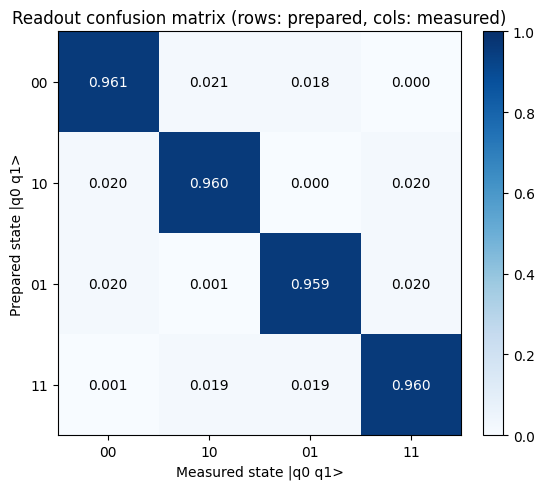

In [ ]:
# Confusion Matrix

def readout_confusion_fidelity(noise_model, shots=8192):
    """
    Build confusion matrix C[prep, meas] by:
    - preparing each computational basis state
    - measuring under the provided noise model
    """
    n_states = 2 ** N_QUBITS
    C = np.zeros((n_states, n_states), dtype=float)

    for prep in range(n_states):
        qc = QuantumCircuit(N_QUBITS)

        # Bits are interpreted as q0 is least-significant bit
        bits = [(prep >> q) & 1 for q in range(N_QUBITS)]
        for q in range(N_QUBITS):
            if bits[q] == 1:
                qc.x(q)

        qc.measure_all()
        counts = sim.run(qc, noise_model=noise_model, shots=shots).result().get_counts()

        # Convert Aer’s bitstring key to [q0,q1]
        for bs, v in counts.items():
            b = bs.replace(" ", "")[::-1]  # now [q0,q1] order
            meas_bits = [int(b[q]) for q in range(N_QUBITS)]
            meas_idx = meas_bits[0] + 2 * meas_bits[1]
            C[prep, meas_idx] += v

    # Normalize each row: sum over measured outcomes equals 1
    row_sums = C.sum(axis=1, keepdims=True)
    C = np.divide(C, row_sums, out=np.zeros_like(C), where=row_sums > 0)

    diag = np.diag(C)
    ro_fid = float(np.mean(diag))
    ro_std = float(np.std(diag))
    return ro_fid, ro_std, C


def idx_to_bitstring(i):
    """Map i -> 'q0q1' string consistent with our confusion indexing:
       i = q0 + 2*q1
    """
    q0 = i & 1
    q1 = (i >> 1) & 1
    return f"{q0}{q1}"


def plot_confusion_matrix(C, title="Readout confusion matrix"):
    labels = [idx_to_bitstring(i) for i in range(C.shape[0])]

    plt.figure(figsize=(6, 5))
    im = plt.imshow(C, vmin=0, vmax=1, cmap="Blues")
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.xticks(range(C.shape[0]), labels)
    plt.yticks(range(C.shape[0]), labels)
    plt.xlabel("Measured state |q0 q1>")
    plt.ylabel("Prepared state |q0 q1>")
    plt.title(title)

    for i in range(C.shape[0]):
        for j in range(C.shape[1]):
            val = C[i, j]
            color = "white" if val > 0.55 else "black"
            plt.text(j, i, f"{val:.3f}", ha="center", va="center", color=color, fontsize=10)

    plt.tight_layout()
    plt.show()

print("Estimating readout metrics (ro_fid, ro_std) ...")
ro_fid, ro_std, C = readout_confusion_fidelity(noise_model, shots=8192)
print(f"  ro_fid  = {ro_fid:.6f}")
print(f"  ro_std  = {ro_std:.6f}")
print("Diagonal confusion values:", np.diag(C))

plot_confusion_matrix(C, title="Readout confusion matrix (rows: prepared, cols: measured)")

## 3) RC (Randomized Compiling) around CZ:

**Problem:** In our model, our noise has both:
- coherent parts (like systematic over-rotation)
- stochastic parts (like depolarizing)

Many theoretical bounds are easier if errors behave “like stochastic Pauli noise”.

**RC idea (Pauli twirling):**
- Before each CZ, we apply a random Pauli \(P\) on the two qubits.
- After the CZ, we apply a corresponding Pauli \(P'\) that compensates so the *ideal circuit behavior is unchanged*.
- With noise, this randomization tends to “average out” coherent structure and makes the effective noise more Pauli-like (incoherent noise).

In code: for every `cz` in a circuit, we replace it by:
$$
\text{(Pauli a⊗b)} \rightarrow \text{CZ} \rightarrow \text{(Pauli ap⊗bp)}
$$

In [ ]:
# Pauli symbols on 1 qubit
_PAULI_1Q = ["I", "X", "Y", "Z"]

def apply_pauli(qc, p, q):
    if p == "X":
        qc.x(q)
    elif p == "Y":
        qc.y(q)
    elif p == "Z":
        qc.z(q)
    # I => do nothing

def cz_twirl_pair(rng_):
    """
    Choose random Pauli (a,b) before CZ and return compensating (ap,bp) after CZ
    such that CZ is unchanged ideally (up to global phase).
    """
    a = _PAULI_1Q[rng_.integers(4)]
    b = _PAULI_1Q[rng_.integers(4)]

    # Conjugation rules for control-Z:
    conj = {
        ("I","I"):("I","I"), ("I","X"):("Z","X"), ("I","Y"):("Z","Y"), ("I","Z"):("I","Z"),
        ("X","I"):("X","Z"), ("X","X"):("Y","Y"), ("X","Y"):("Y","X"), ("X","Z"):("X","I"),
        ("Y","I"):("Y","Z"), ("Y","X"):("X","Y"), ("Y","Y"):("X","X"), ("Y","Z"):("Y","I"),
        ("Z","I"):("Z","I"), ("Z","X"):("I","X"), ("Z","Y"):("I","Y"), ("Z","Z"):("Z","Z"),
    }
    ap, bp = conj[(a, b)]
    return (a, b), (ap, bp)

def randomly_compile_rc_around_cz(qc, rng_):
    """
    Replace each CZ with: Pauli(a,b) -> CZ -> Pauli(ap,bp).
    """
    out = QuantumCircuit(N_QUBITS)

    for inst in qc.data:
        if inst.operation.name == "cz":
            (a, b), (ap, bp) = cz_twirl_pair(rng_)
            apply_pauli(out, a, 0)
            apply_pauli(out, b, 1)
            out.cz(0, 1)
            apply_pauli(out, ap, 0)
            apply_pauli(out, bp, 1)
        else:
            out.append(inst.operation, inst.qubits)

    return out

def run_rc_averaged(qc, noise_model, rng_, shots=SHOTS, n_rc=N_RC):
    """
    Apply RC randomizations n_rc times and average the resulting measured probabilities.
    """
    total = {}
    per = max(shots // n_rc, 1)

    for _ in range(n_rc):
        rc = randomly_compile_rc_around_cz(qc, rng_)
        rc.measure_all()

        result = sim.run(rc, noise_model=noise_model, shots=per).result()
        counts = result.get_counts()

        for k, v in counts.items():
            total[k] = total.get(k, 0) + v

    tot = sum(total.values())
    return {k: v / tot for k, v in total.items()}

## 4) Metrics: TVD, Hellinger fidelity, and Shannon entropy

We will repeatedly compare:
- **ideal probability distribution** $p$ from the statevector
- **measured distribution** $q$ from noisy RC-sampled circuits

### TVD (Total Variation Distance)
$$
\mathrm{TVD}(p,q) = \frac{1}{2}\sum_x |p(x)-q(x)|
$$
Range: 0 (identical) to 1 (maximally different).

### Hellinger fidelity (distribution-based)
We use:
$$
F_H(p,q)=\left(\sum_x \sqrt{p(x)q(x)}\right)^2
$$

### Shannon entropy of the ideal distribution
$$
H(p)=-\sum_x p(x)\ln p(x)
$$
Higher entropy means the ideal distribution is more “spread out”.
We’ll use entropy to see how the bound-vs-data discrepancy correlates with circuit structure.

In [ ]:
# Metric Functions

def ideal_probs(qc):
    """Return ideal probabilities p(x) as a probability dict."""
    return Statevector.from_instruction(qc).probabilities_dict()

def tvd_from_prob_dicts(p, q):
    keys = set(p) | set(q)
    return 0.5 * sum(abs(p.get(k, 0.0) - q.get(k, 0.0)) for k in keys)

def hellinger_fidelity_from_prob_dicts(p, q):
    keys = set(p) | set(q)
    s = 0.0
    for k in keys:
        pk = p.get(k, 0.0)
        qk = q.get(k, 0.0)
        if pk > 0 and qk > 0:
            s += np.sqrt(pk * qk)
    return float(s * s)

def shannon_entropy_from_prob_dicts(p):
    ent = 0.0
    for pk in p.values():
        if pk > 0:
            ent -= pk * np.log(pk)  # natural log
    return float(ent)

## 5) CB (Cycle Benchmarking): how we estimate \(e_F\)

CB is a way to measure *how quickly certain observables decay* as you repeat a noisy gate cycle.

Here’s the simplified idea:
1. Pick a 2-qubit Pauli operator $P$ (like $Z\otimes Z$, $X\otimes I$, etc.).
2. Prepare a +1 eigenstate of $P$.
3. Repeat a noisy “cycle” $m$ times (here: a CZ cycle implemented with RC twirling).
4. Measure in the eigenbasis of $P$ and compute the expectation value $\langle P \rangle_m$.
5. Repeat for different $m$ and fit:
   $$
   |\langle P \rangle_m| \approx A \, p^m
   $$
   where \(p\) is an effective survival/decay parameter.

Then we convert these per-P decay parameters into a single process infidelity proxy $e_F$.

In [ ]:
# CB Helper Functions nad CB Fit Function

def pauli_ev_from_counts(counts, P):
    """
    Estimate expectation value of Pauli string P from bitstring counts.

    We:
    - rotate measurement basis so we measure eigenvalue parity of P
    - then parity of measured bits tells whether eigenvalue is +1 or -1
    """
    support = [q for q, c in enumerate(P) if c != "I"]
    tot = sum(counts.values())
    acc = 0

    for bs, c in counts.items():
        # Aer keys are like "c1c0"; reverse -> [q0,q1]
        b = bs.replace(" ", "")[::-1]
        parity = sum(int(b[q]) for q in support) % 2
        acc += c * (1 if parity == 0 else -1)

    return acc / tot

def prep_and_measure_rotations(qc, P, meas=False):
    """
    Rotate qubits to prepare/measure +1 eigenstates or eigenbases for Pauli P.

    For single-qubit mapping:
    - X basis: apply H
    - Y basis: prep uses H S, measurement uses Sdg H (so that Y eigenbasis -> Z)
    """
    for q, c in enumerate(P):
        if c == "X":
            qc.h(q)
        elif c == "Y":
            if meas:
                qc.sdg(q)
                qc.h(q)
            else:
                qc.h(q)
                qc.s(q)
        elif c == "Z":
            pass
        elif c == "I":
            pass
        else:
            raise ValueError(c)

def cb_cz_estimate_eF(noise_model, rng_, paulis=None):
    """
    Estimate e_F by fitting per-P Pauli decay terms with CB on repeated CZ cycles.

    Returns:
      e_F, e_F_std, f_estimates, f_stds, cb_details
    """
    if paulis is None:
        paulis = [a + b for a in _PAULI_1Q for b in _PAULI_1Q if not (a == "I" and b == "I")]

    f_estimates = []
    f_stds = []
    cb_details = {}

    # CB fits
    for P in paulis:
        surv_means = []
        surv_stds = []

        for m in CB_DEPTHS:
            vals = []
            for _ in range(CB_N_RC):
                qc = QuantumCircuit(N_QUBITS)

                # prepare +1 eigenstate of P
                prep_and_measure_rotations(qc, P, meas=False)

                # apply m CZ cycles, each using RC twirling/correction around CZ
                for _step in range(m):
                    (a, b), (ap, bp) = cz_twirl_pair(rng_)
                    apply_pauli(qc, a, 0)
                    apply_pauli(qc, b, 1)
                    qc.cz(0, 1)
                    apply_pauli(qc, ap, 0)
                    apply_pauli(qc, bp, 1)

                # rotate measurement basis for P and measure
                prep_and_measure_rotations(qc, P, meas=True)
                qc.measure_all()

                counts = sim.run(qc, noise_model=noise_model, shots=CB_SHOTS).result().get_counts()
                vals.append(pauli_ev_from_counts(counts, P))

            surv_means.append(float(np.mean(vals)))
            surv_stds.append(float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0)

        # Fit |surv(m)| = A * (f^m)
        m_arr = np.array(CB_DEPTHS, dtype=float)
        s_arr = np.abs(np.array(surv_means, dtype=float))

        try:
            popt, pcov = curve_fit(
                lambda m, A, f: A * (f ** m),
                m_arr,
                s_arr,
                p0=[1.0, 0.99],
                bounds=([0.0, 0.0], [2.0, 1.0]),
                maxfev=20000,
            )
            A_hat, f_hat = popt
            f_std = float(np.sqrt(np.maximum(pcov[1, 1], 0.0)))
        except Exception:
            f_hat = float(s_arr[0] ** (1.0 / CB_DEPTHS[0]))
            f_std = 0.05
            A_hat = float(s_arr[0])

        sign0 = 1.0 if surv_means[0] == 0 else float(np.sign(surv_means[0]))

        cb_details[P] = {
            "A": float(A_hat),
            "p": float(f_hat),
            "p_std": float(f_std),
            "surv_means": np.array(surv_means, dtype=float),
            "surv_stds": np.array(surv_stds, dtype=float),
            "sign0": sign0,
        }

        f_estimates.append(f_hat)
        f_stds.append(f_std)

    f_estimates = np.array(f_estimates, dtype=float)
    f_stds = np.array(f_stds, dtype=float)

    # Convert fitted decay parameters into overall e_F.
    # (This toy reproduction uses: e_F ≈ mean(1 - f_P))
    e_F = float(np.mean(1.0 - f_estimates))

    # Uncertainty: Var(mean(1-f)) ≈ sum Var(f_P)/N^2 (independence approximation)
    Np = len(f_estimates)
    e_F_var = float(np.sum(f_stds ** 2)) / (Np ** 2)
    e_F_std = float(np.sqrt(max(e_F_var, 0.0)))

    return e_F, e_F_std, f_estimates, f_stds, cb_details

In [ ]:
# CB Plotting Functions

def pauli_term_order_16():
    """
    A common labeling order for the 16 two-qubit Pauli terms (including II).
    We use it for plotting the bar chart.
    """
    return [
        "II",
        "IX", "IY", "IZ",
        "XI", "XX", "XY", "XZ",
        "YI", "YX", "YY", "YZ",
        "ZI", "ZX", "ZY", "ZZ",
    ]

def plot_cb_expectations(cb_details):
    """
    Plot expectation-value vs sequence length for each Pauli term (excluding II),
    with fitted exponential overlay.
    """
    plt.figure(figsize=(12, 6))
    xs = np.array(CB_DEPTHS, dtype=float)

    for P, d in cb_details.items():
        means = d["surv_means"]
        stds = d["surv_stds"]
        A = d["A"]
        p = d["p"]
        sign0 = d["sign0"]

        # data points
        plt.errorbar(xs, means, yerr=stds, fmt="o", capsize=3, alpha=0.7, linewidth=1)
        # fit overlay
        yfit = sign0 * A * (p ** xs)
        plt.plot(xs, yfit, linewidth=2, alpha=0.8)

    plt.title("CB on CZ cycle: expectation curves with exponential fits")
    plt.xlabel("Sequence Length")
    plt.ylabel("Expectation Value <P>")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_cb_pauli_infidelity(cb_details, e_F=None):
    """
    Plot per-P infidelity proxy e_P = 1 - p_P (from CB fits), including II=0.
    """
    order = pauli_term_order_16()

    e_vals = []
    e_errs = []

    for term in order:
        if term == "II":
            e_vals.append(0.0)
            e_errs.append(0.0)
        else:
            e_vals.append(1.0 - cb_details[term]["p"])
            e_errs.append(cb_details[term]["p_std"])

    plt.figure(figsize=(12, 6))
    x = np.arange(len(order))

    plt.bar(x, e_vals, yerr=e_errs, capsize=3, alpha=0.9)

    if e_F is not None:
        plt.axhline(e_F, color="C0", linestyle="--", linewidth=2, label="e_F: process infidelity")

    plt.ylabel("Infidelity (1 - p for Pauli decay term)")
    plt.xlabel("Pauli decay term")
    plt.title("Pauli infidelities from CB fits")
    plt.xticks(x, order, rotation=45, ha="right")
    plt.grid(True, axis="y", alpha=0.25)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

Estimating CB process parameter e_F ...
  e_F     = 0.017385
  e_F_std = 0.000304


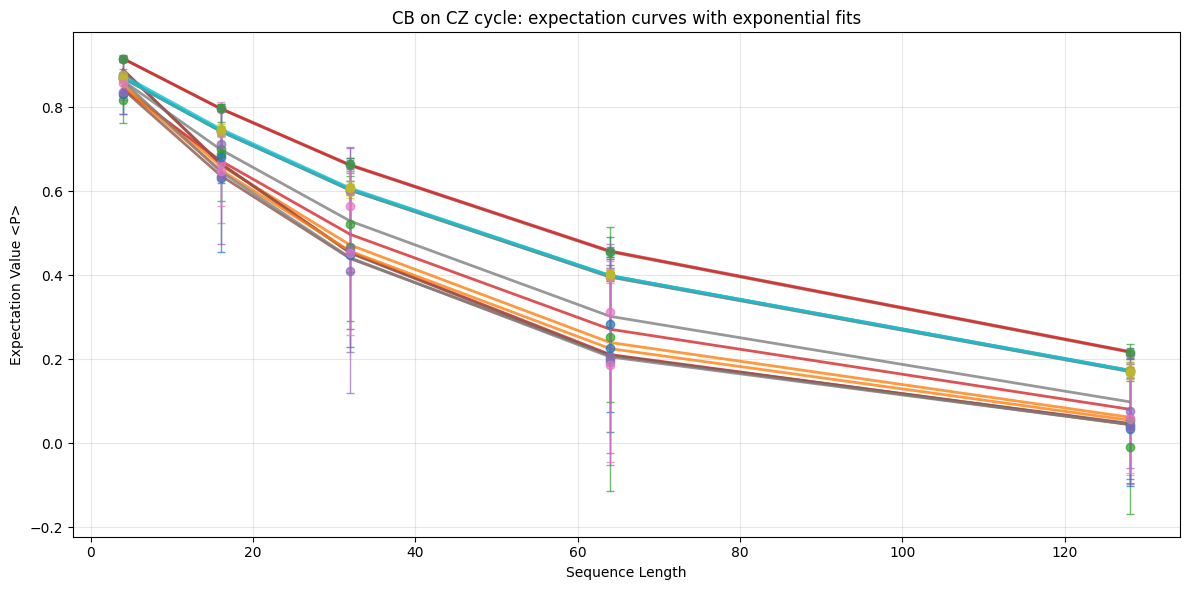

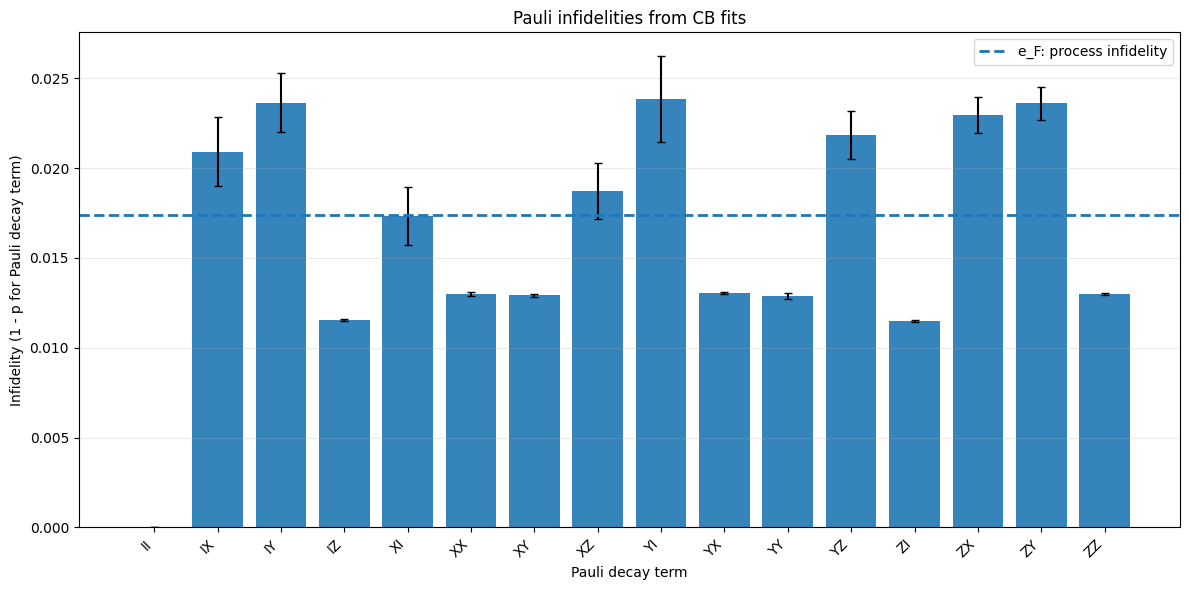

In [ ]:
# Run CB to get e_F

print("Estimating CB process parameter e_F ...")
e_F, e_F_std, f_estimates, f_stds, cb_details = cb_cz_estimate_eF(noise_model, rng)
print(f"  e_F     = {e_F:.6f}")
print(f"  e_F_std = {e_F_std:.6f}")

plot_cb_expectations(cb_details)
plot_cb_pauli_infidelity(cb_details, e_F=e_F)

## 6) QCAP bound algebra (how we get a predicted error curve)

In QCAP-style analysis we want a bound on an “error probability” term.

This code uses the same closed-form algebra:

For each circuit depth \(d\):
- define
  $$
  y = (1-e_F)^d
  $$
- propagate uncertainty from $e_F$ via $e_F^{std}$
- combine with readout parameters $r_o^{fid}$ and $r_o^{std}$

Then we compute:
- `bounds[d]` = the predicted QCAP error probability
- `bounds_unc[d]` = its uncertainty (1-sigma)
- we plot a **2.96σ** band (roughly 99% coverage if Gaussian-ish)

We’ll also relate fidelity line as:
$$
\text{fidelity line} \approx 1 - \text{QCAP error bound}
$$

In [ ]:
# Compute Bound

def qcap_bound_from_ro_and_eF(depths, ro_fid, ro_std, e_F, e_F_std):
    bounds = []
    unc = []

    for d in depths:
        # y = (1-e_F)^d
        y = (1.0 - e_F) ** d

        # uncertainty propagation for y
        yvar = d * (1.0 - e_F) ** (d - 1) * (e_F_std ** 2)

        p0 = ro_fid
        pvar0 = ro_std ** 2

        # combine readout variance with process variance
        pvar = pvar0 * (yvar + y ** 2) + yvar * (p0 ** 2)

        # effective probability of error
        p = p0 * y

        # e_IU = 1 - p
        eIU = 1.0 - p
        eIU_std = float(np.sqrt(max(pvar, 0.0)))

        bounds.append(float(eIU))
        unc.append(eIU_std)

    return np.array(bounds, dtype=float), np.array(unc, dtype=float)

## 7) Circuit families: what circuits are we testing?

We will run two families:
1. **Random family**: layers of random 1‑qubit unitaries, plus a CZ at the end of each cycle.
2. **Structured family**: each layer uses a simple choice among {I, H, X} for each qubit, then CZ.

The "depth” here means: how many CZ cycles we repeat.
As depth increases, noise compounds, and the measured distance from the ideal should increase.

In [ ]:
# Generate Circuit Families

def make_random_circuit(depth, rng_):
    qc = QuantumCircuit(N_QUBITS)
    for _ in range(depth):
        for q in range(N_QUBITS):
            qc.append(random_unitary(2, seed=int(rng_.integers(1 << 31))), [q])
        qc.cz(0, 1)
    return qc

def make_structured_circuit(depth, rng_):
    qc = QuantumCircuit(N_QUBITS)
    gates = ["i", "h", "x"]
    for _ in range(depth):
        for q in range(N_QUBITS):
            g = gates[int(rng_.integers(3))]
            if g == "h":
                qc.h(q)
            elif g == "x":
                qc.x(q)
        qc.cz(0, 1)
    return qc

## 8) Main experiment loop: compare measured metrics vs QCAP bound

For each depth `d` and each circuit instance:
- compute ideal distribution `p` using a statevector
- run noisy RC-randomized circuit to get measured distribution `q`
- compute:
  - TVD(p,q)
  - Hellinger fidelity(p,q)
  - Shannon entropy of ideal p

Then plot:
1) Scatter of TVD vs depth + QCAP bound line + uncertainty band
2) Scatter of Hellinger fidelity vs depth + fidelity bound line + uncertainty band
3) A diagnostic scatter: `(Bound - TVD)` vs Shannon entropy

In [ ]:
# Run and plot each circuit type

def run_family_and_plot(
    family_name,
    circuit_generator,
    noise_model,
    rng_,
    ro_fid, ro_std, e_F, e_F_std,
    depths=DEPTHS,
    n_circ=N_CIRC_PER_DEPTH,
    shots=SHOTS,
    n_rc=N_RC,
):
    bounds, bounds_unc = qcap_bound_from_ro_and_eF(depths, ro_fid, ro_std, e_F, e_F_std)

    tvds = [[] for _ in depths]
    fids = [[] for _ in depths]
    entropies = [[] for _ in depths]

    # Collect samples
    for di, d in enumerate(depths):
        for _ in range(n_circ):
            qc = circuit_generator(d, rng_)

            ideal = ideal_probs(qc)
            meas = run_rc_averaged(qc, noise_model, rng_, shots=shots, n_rc=n_rc)

            tvd = tvd_from_prob_dicts(ideal, meas)
            fid = hellinger_fidelity_from_prob_dicts(ideal, meas)
            entr = shannon_entropy_from_prob_dicts(ideal)

            tvds[di].append(tvd)
            fids[di].append(fid)
            entropies[di].append(entr)

    # ---- Plot TVD with bound ----
    plt.figure(figsize=(10, 6))
    first = True
    for di, d in enumerate(depths):
        y = tvds[di]
        if not y:
            continue
        plt.scatter(
            [d] * len(y), y,
            s=30, alpha=0.8, color="b",
            label="measured TVD (RC)" if first else None
        )
        first = False

    plt.plot(depths, bounds, "-", color="blue", label="Bound (QCAP)")
    plt.fill_between(
        depths,
        bounds - 2.96 * bounds_unc,
        bounds + 2.96 * bounds_unc,
        color="blue",
        alpha=0.3
    )

    plt.legend(loc=0, fontsize=12)
    plt.xlabel("Circuit depth", fontsize=14)
    plt.ylabel("Probability of an Error (TVD)", fontsize=14)
    plt.grid(True)
    plt.title(f"{family_name} family")
    plt.tight_layout()
    plt.show()

    # ---- Plot Hellinger fidelity with bound ----
    plt.figure(figsize=(10, 6))
    first = True
    for di, d in enumerate(depths):
        y = fids[di]
        if not y:
            continue
        plt.scatter(
            [d] * len(y), y,
            s=30, alpha=0.8, color="b",
            label="measured Hellinger fidelity" if first else None
        )
        first = False

    qcap_fid = 1.0 - bounds
    plt.plot(depths, qcap_fid, "-", color="blue", label="Bound line (1 - QCAP error)")

    fid_low = 1.0 - (bounds + 2.96 * bounds_unc)
    fid_high = 1.0 - (bounds - 2.96 * bounds_unc)
    plt.fill_between(depths, fid_low, fid_high, color="blue", alpha=0.3)

    plt.legend(loc=0, fontsize=12)
    plt.xlabel("Circuit depth", fontsize=14)
    plt.ylabel("Hellinger Fidelity", fontsize=14)
    plt.grid(True)
    plt.title(f"{family_name} family")
    plt.tight_layout()
    plt.show()

    # ---- Plot (Bound - TVD) vs Shannon entropy (ideal) ----
    diffs = []
    xent = []

    for di in range(len(depths)):
        for j in range(len(tvds[di])):
            diffs.append(bounds[di] - tvds[di][j])  # signed: Bound - TVD
            xent.append(entropies[di][j])

    plt.figure(figsize=(10, 6))
    plt.plot(np.array(xent), np.array(diffs), "o", color="b")
    plt.xlabel("Shannon Entropy (ideal)", fontsize=14)
    plt.ylabel("Bound - TVD", fontsize=14)
    plt.grid(True)
    plt.title(f"{family_name} family")
    plt.tight_layout()
    plt.show()


Running families + plotting...


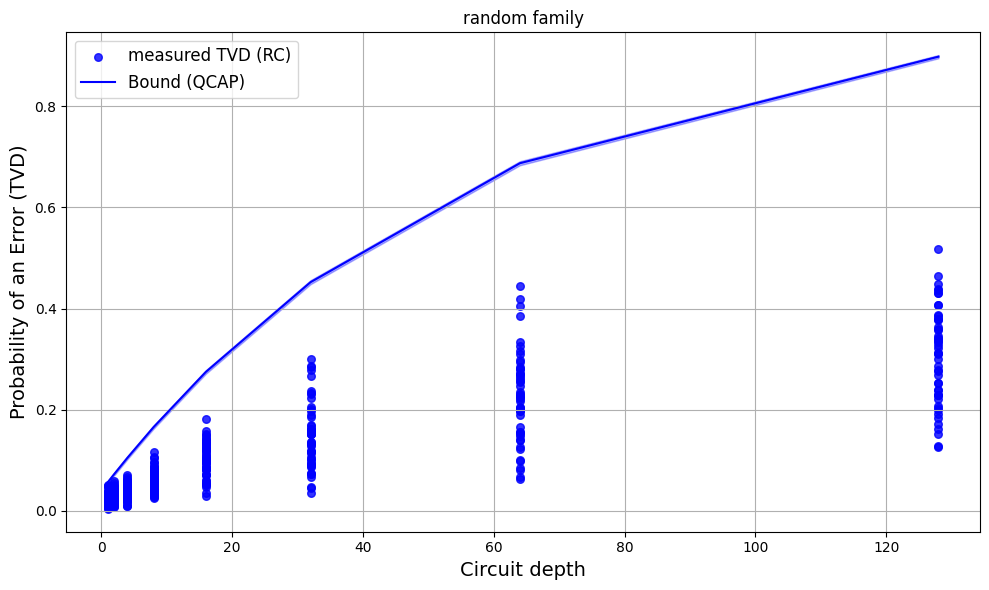

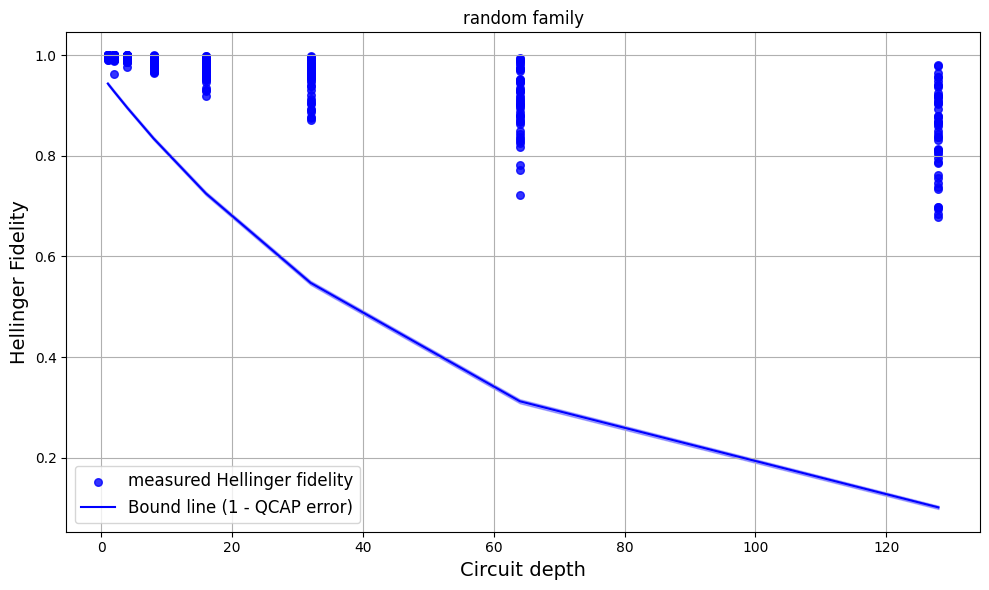

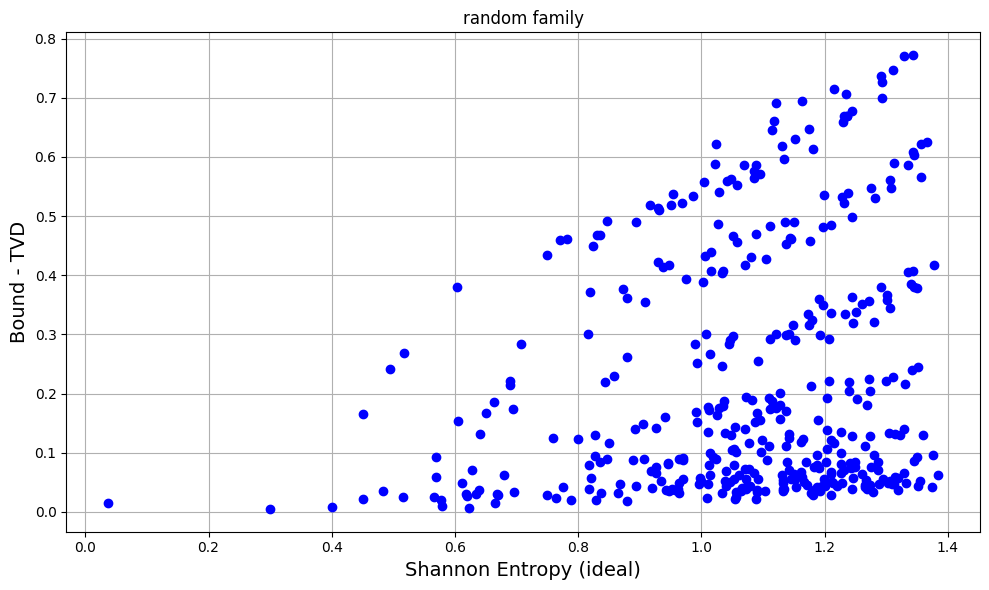

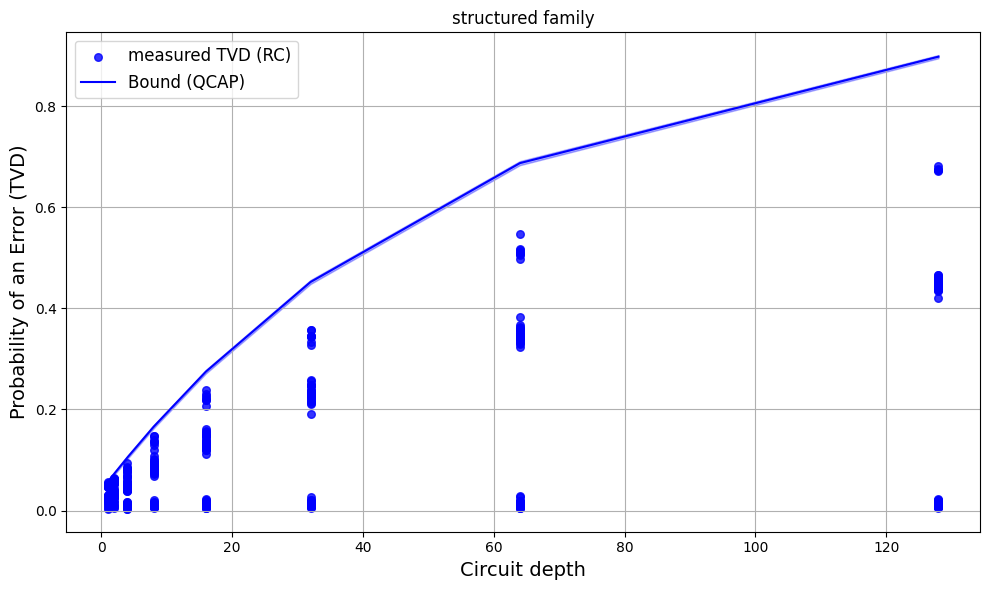

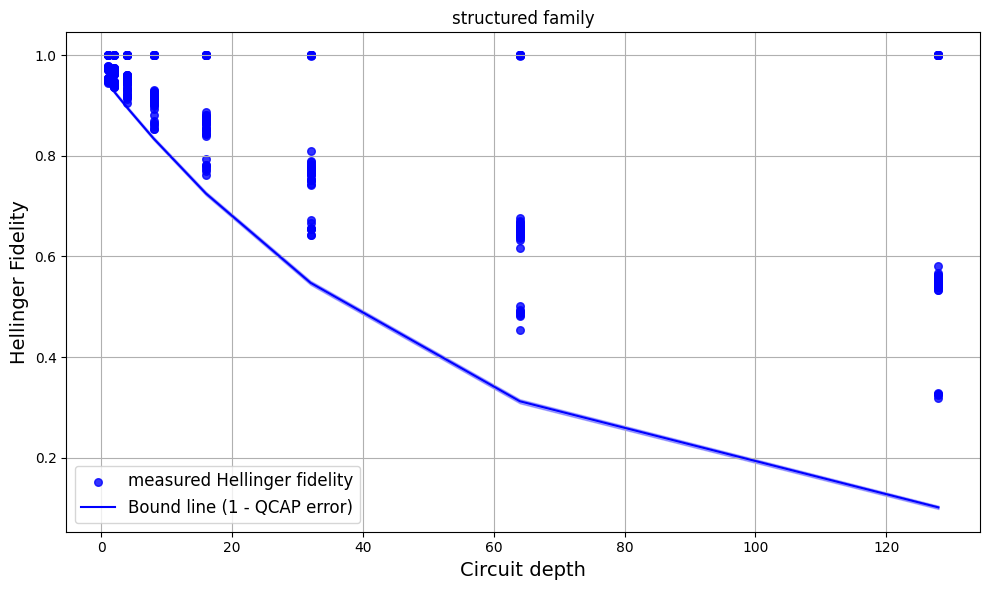

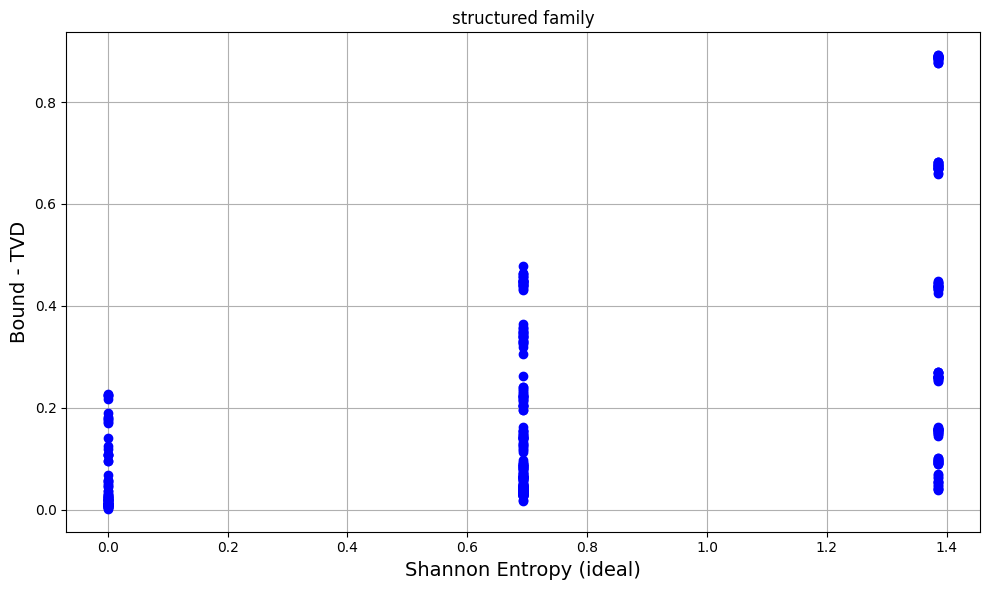

In [ ]:
print("\nRunning families + plotting...")
families = [
    ("random", make_random_circuit),
    ("structured", make_structured_circuit),
]

for family_name, gen in families:
    run_family_and_plot(
        family_name=family_name,
        circuit_generator=gen,
        noise_model=noise_model,
        rng_=rng,
        ro_fid=ro_fid,
        ro_std=ro_std,
        e_F=e_F,
        e_F_std=e_F_std,
        depths=DEPTHS,
        n_circ=N_CIRC_PER_DEPTH,
        shots=SHOTS,
        n_rc=N_RC,
    )